# Fire Tile Classification Validation

This notebook validates the HydraNet fire checkpoint against the HuggingFace `sirbastiano94/fire` Zarr dataset using the fire task's actual tile-classification contract.

Workflow:
1. Download a compact four-class subset of already tiled fire data from HuggingFace.
2. Preserve each `256 x 256 x 8` tile, and use the same tiling helper for larger `C x H x W` acquisitions.
3. Load the HydraNet fire checkpoint with its classifier head.
4. Run 4-class tile inference for `Safe`, `Fire`, `Burnt`, and `Water`.
5. Report tile-level metrics and save a validation montage.


## Class And Tiling Contract

The fire task is not a binary image-level task. The dataset described for this work starts from simulated `4096 x 4096 x 8` PhiSat-2 acquisitions, then divides each acquisition into `256 x 256 x 8` tiles. Each tile receives one of four labels:

- `0`: Safe
- `1`: Fire
- `2`: Burnt
- `3`: Water

The HuggingFace repository already stores the post-tiling samples as Zarr groups where `img` is an 8-band tile and `label` is a scalar class ID. This notebook keeps the tile size at 256 and does not center-crop to 224.


In [1]:
from pathlib import Path

DATASET_REPO = "sirbastiano94/fire"
ZARR_NAME = "fire_dataset.zarr"
MODEL_TASK = "fire"
TRAINING = "linear_probing"
N_SHOTS = 100
TILE_SIZE = 256
N_TILES_PER_CLASS = 3

# The public test split contains all four classes. The trainval subset in this repo only exposes Safe/Fire.
VALIDATION_GROUP = "test"
AUTO_DOWNLOAD = True
HF_DOWNLOAD_WORKERS = 12

CLASS_NAMES = ("Safe", "Fire", "Burnt", "Water")
CLASS_IDS = {name: idx for idx, name in enumerate(CLASS_NAMES)}

# Deterministic compact showcase subset from the test split.
# Set RUN_FULL_TEST_SET=True below only if you intentionally want to download several GB of tile data.
PREFERRED_SAMPLE_IDS_BY_CLASS = {
    "Safe": ("0000000", "0000001", "0000002"),
    "Fire": ("0002291", "0002292", "0002293"),
    "Burnt": ("0002688", "0002689", "0002690"),
    "Water": ("0003109", "0003110", "0003111"),
}
RUN_FULL_TEST_SET = False

DATA_ROOT = Path.home() / ".cache" / "hydranet" / "fire"
HF_SAMPLE_ROOT = DATA_ROOT / "hf-fire-tile-samples"
ZARR_PATH = HF_SAMPLE_ROOT / ZARR_NAME
OUTPUT_DIR = DATA_ROOT / "outputs"
WEIGHTS_DIR = DATA_ROOT / "weights"
ZARR_MARKERS = (".zgroup", "zarr.json")
RGB_BANDS = (3, 2, 1)  # B4, B3, B2 from the stored B1-B8 band order.


def looks_like_zarr_store(path: Path) -> bool:
    return any((path / marker).exists() for marker in ZARR_MARKERS)


def preferred_sample_ids() -> tuple[str, ...]:
    ids = []
    for class_name in CLASS_NAMES:
        ids.extend(PREFERRED_SAMPLE_IDS_BY_CLASS[class_name][:N_TILES_PER_CLASS])
    return tuple(ids)


HF_SAMPLE_IDS = preferred_sample_ids()

DATA_ROOT.mkdir(parents=True, exist_ok=True)
HF_SAMPLE_ROOT.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
WEIGHTS_DIR.mkdir(parents=True, exist_ok=True)

print(f"dataset_repo: {DATASET_REPO}")
print(f"data_root: {DATA_ROOT}")
print(f"zarr_path: {ZARR_PATH}")
print(f"validation_group: {VALIDATION_GROUP}")
print(f"tile_size: {TILE_SIZE}")
print(f"class_names: {CLASS_NAMES}")
print(f"sample_ids: {HF_SAMPLE_IDS}")
print(f"run_full_test_set: {RUN_FULL_TEST_SET}")


dataset_repo: sirbastiano94/fire
data_root: /Users/roberto.delprete/.cache/hydranet/fire
zarr_path: /Users/roberto.delprete/.cache/hydranet/fire/hf-fire-tile-samples/fire_dataset.zarr
validation_group: test
tile_size: 256
class_names: ('Safe', 'Fire', 'Burnt', 'Water')
sample_ids: ('0000000', '0000001', '0000002', '0002291', '0002292', '0002293', '0002688', '0002689', '0002690', '0003109', '0003110', '0003111')
run_full_test_set: False


## Download A Small Four-Class Tile Subset

The dataset is a raw Zarr tree, so the notebook downloads only the selected sample groups plus root metadata. The selected default subset keeps the notebook lightweight while still covering all four fire classes.


In [2]:
from concurrent.futures import ThreadPoolExecutor, as_completed
from huggingface_hub import HfApi


def list_group_sample_ids(api: HfApi, repo_id: str, group_name: str) -> tuple[str, ...]:
    ids = []
    prefix = f"{ZARR_NAME}/{group_name}"
    for item in api.list_repo_tree(repo_id=repo_id, repo_type="dataset", path_in_repo=prefix, recursive=False):
        sample_id = item.path.rsplit("/", 1)[-1]
        if sample_id.isdigit():
            ids.append(sample_id)
    return tuple(sorted(ids))


def hf_subset_is_available(zarr_path: Path, group_name: str, sample_ids: tuple[str, ...]) -> bool:
    if not looks_like_zarr_store(zarr_path):
        return False
    if not (zarr_path / group_name / ".zgroup").exists():
        return False
    return all(
        (zarr_path / group_name / sample_id / ".zgroup").exists()
        and (zarr_path / group_name / sample_id / "img" / ".zarray").exists()
        and (zarr_path / group_name / sample_id / "label" / ".zarray").exists()
        and (zarr_path / group_name / sample_id / "label" / "0").exists()
        for sample_id in sample_ids
    )


def existing_repo_paths(api: HfApi, repo_id: str, paths: list[str]) -> list[str]:
    infos = api.get_paths_info(repo_id=repo_id, repo_type="dataset", paths=paths)
    found = {info.path for info in infos}
    return [path for path in paths if path in found]


def list_sample_files(api: HfApi, repo_id: str, group_name: str, sample_id: str) -> list[str]:
    prefix = f"{ZARR_NAME}/{group_name}/{sample_id}"
    files = []
    for item in api.list_repo_tree(repo_id=repo_id, repo_type="dataset", path_in_repo=prefix, recursive=True):
        if type(item).__name__ == "RepoFile":
            files.append(item.path)
    if not files:
        raise FileNotFoundError(f"No files found in {repo_id}:{prefix}")
    return sorted(files)


def download_hf_zarr_subset(repo_id: str, sample_ids: tuple[str, ...], group_name: str, local_root: Path) -> Path:
    api = HfApi()
    metadata_candidates = [
        f"{ZARR_NAME}/.zgroup",
        f"{ZARR_NAME}/.zattrs",
        f"{ZARR_NAME}/{group_name}/.zgroup",
        f"{ZARR_NAME}/{group_name}/.zattrs",
    ]
    paths = existing_repo_paths(api, repo_id, metadata_candidates)
    for sample_id in sample_ids:
        paths.extend(list_sample_files(api, repo_id, group_name, sample_id))

    paths = list(dict.fromkeys(paths))
    local_root.mkdir(parents=True, exist_ok=True)
    print(f"Downloading {len(paths)} files from {repo_id} into {local_root}", flush=True)

    def download_one(repo_path: str) -> str:
        api.hf_hub_download(
            repo_id=repo_id,
            repo_type="dataset",
            filename=repo_path,
            local_dir=local_root,
        )
        return repo_path

    with ThreadPoolExecutor(max_workers=HF_DOWNLOAD_WORKERS) as executor:
        futures = [executor.submit(download_one, repo_path) for repo_path in paths]
        for index, future in enumerate(as_completed(futures), start=1):
            future.result()
            if index == 1 or index == len(paths) or index % 25 == 0:
                print(f"  downloaded {index}/{len(paths)}", flush=True)

    zarr_path = local_root / ZARR_NAME
    if not looks_like_zarr_store(zarr_path):
        raise FileNotFoundError(f"Downloaded subset, but no Zarr root was found at {zarr_path}")
    return zarr_path


if RUN_FULL_TEST_SET:
    HF_SAMPLE_IDS = list_group_sample_ids(HfApi(), DATASET_REPO, VALIDATION_GROUP)
    print(f"Full split selected: {len(HF_SAMPLE_IDS)} samples")

if hf_subset_is_available(ZARR_PATH, VALIDATION_GROUP, HF_SAMPLE_IDS):
    print(f"Using existing HF Zarr subset: {ZARR_PATH}")
elif AUTO_DOWNLOAD:
    ZARR_PATH = download_hf_zarr_subset(DATASET_REPO, HF_SAMPLE_IDS, VALIDATION_GROUP, HF_SAMPLE_ROOT)
    print(f"Using downloaded HF Zarr subset: {ZARR_PATH}")
else:
    raise FileNotFoundError(f"Zarr subset not found at {ZARR_PATH}. Set AUTO_DOWNLOAD=True or point ZARR_PATH to a local store.")


Using existing HF Zarr subset: /Users/roberto.delprete/.cache/hydranet/fire/hf-fire-tile-samples/fire_dataset.zarr


## Open The Zarr Store

The selected group contains tile sample directories with `img`, `label`, and metadata attributes.


In [3]:
import zarr

root = zarr.open_group(str(ZARR_PATH), mode="r")
root_keys = list(root.keys())
print("root groups:", root_keys[:20])

if VALIDATION_GROUP not in root:
    raise KeyError(f"Group {VALIDATION_GROUP!r} not found in {ZARR_PATH}")

sample_group = root[VALIDATION_GROUP]
sample_group_keys = list(sample_group.keys())
print(f"selected sample group: {VALIDATION_GROUP}")
print(f"number of child entries: {len(sample_group_keys)}")


root groups: ['test']
selected sample group: test
number of child entries: 12


## Tile Loading Helpers

The helper `tile_chw_image` is the important part: it turns a channel-first acquisition into non-overlapping `256 x 256` tiles. For the HuggingFace Zarr samples this returns one tile because those samples are already post-tiling outputs.


In [4]:
import numpy as np


def to_chw(image: np.ndarray) -> np.ndarray:
    image = np.asarray(image)
    if image.ndim != 3:
        raise ValueError(f"Expected image with 3 dimensions, got shape {image.shape}")
    if image.shape[0] <= 32:
        return image.astype(np.float32, copy=False)
    if image.shape[-1] <= 32:
        return np.moveaxis(image, -1, 0).astype(np.float32, copy=False)
    raise ValueError(f"Could not infer channel axis from image shape {image.shape}")


def decode_scalar_label(label_array) -> int:
    value = float(np.asarray(label_array)[()])
    label = int(round(value))
    if label not in range(len(CLASS_NAMES)):
        raise ValueError(f"Expected fire label 0..{len(CLASS_NAMES) - 1}, got {value}")
    return label


def parse_band_order(attrs: dict) -> tuple[str, ...]:
    raw = str(attrs.get("spectral_bands_ordered", "") or "")
    return tuple(part.strip() for part in raw.split("-") if part.strip())


def tile_chw_image(image_chw: np.ndarray, tile_size: int) -> list[dict]:
    image_chw = to_chw(image_chw)
    channels, height, width = image_chw.shape
    if height < tile_size or width < tile_size:
        raise ValueError(f"Image shape {image_chw.shape} is smaller than tile size {tile_size}")
    if height % tile_size != 0 or width % tile_size != 0:
        raise ValueError(f"Image shape {image_chw.shape} is not evenly divisible by tile size {tile_size}")

    tiles = []
    for top in range(0, height, tile_size):
        for left in range(0, width, tile_size):
            row = top // tile_size
            col = left // tile_size
            tiles.append(
                {
                    "tile": image_chw[:, top:top + tile_size, left:left + tile_size],
                    "row": row,
                    "col": col,
                    "top": top,
                    "left": left,
                }
            )
    return tiles


def standardize_per_channel(image_chw: np.ndarray) -> np.ndarray:
    image = image_chw.astype(np.float32, copy=True)
    mean = np.nanmean(image, axis=(1, 2), keepdims=True)
    std = np.nanstd(image, axis=(1, 2), keepdims=True)
    return (image - mean) / (std + 1e-6)


def sample_has_arrays(container, sample_id: str) -> bool:
    try:
        sample = container[sample_id]
        return hasattr(sample, "keys") and "img" in sample and "label" in sample
    except Exception:
        return False


def load_sample_tiles(container, sample_id: str, tile_size: int) -> list[dict]:
    sample = container[sample_id]
    attrs = dict(sample.attrs)
    image_chw = to_chw(np.asarray(sample["img"]))
    label = decode_scalar_label(sample["label"])
    tiles = tile_chw_image(image_chw, tile_size)

    records = []
    for tile_index, tile_record in enumerate(tiles):
        tile = tile_record["tile"]
        records.append(
            {
                "sample_id": sample_id,
                "tile_id": f"{sample_id}:{tile_record['row']},{tile_record['col']}",
                "tile_index": tile_index,
                "tile_row": tile_record["row"],
                "tile_col": tile_record["col"],
                "tile_origin": (tile_record["top"], tile_record["left"]),
                "image": tile,
                "model_input": standardize_per_channel(tile),
                "label": label,
                "label_name": CLASS_NAMES[label],
                "source_band_order": parse_band_order(attrs),
                "preprocessing": "per-tile channel standardization",
                "attrs": attrs,
            }
        )
    return records


In [5]:
records = []
missing_samples = []
for sample_id in HF_SAMPLE_IDS:
    if sample_has_arrays(sample_group, sample_id):
        records.extend(load_sample_tiles(sample_group, sample_id, TILE_SIZE))
    else:
        missing_samples.append(sample_id)

if missing_samples:
    print(f"missing samples skipped: {missing_samples}")
if not records:
    raise ValueError("No tile records were loaded.")

labels = np.array([record["label"] for record in records], dtype=np.int64)
class_counts = {name: int(np.sum(labels == class_id)) for name, class_id in CLASS_IDS.items()}

print("loaded tile records:", len(records))
print("tile ids:", [record["tile_id"] for record in records])
print("label counts:", class_counts)
print("image shape:", records[0]["image"].shape)
print("model input shape:", records[0]["model_input"].shape)
print("source band orders:", sorted(set(record["source_band_order"] for record in records)))
print("preprocessing:", records[0]["preprocessing"])
print("tile origins:", [record["tile_origin"] for record in records])


loaded tile records: 12
tile ids: ['0000000:0,0', '0000001:0,0', '0000002:0,0', '0002291:0,0', '0002292:0,0', '0002293:0,0', '0002688:0,0', '0002689:0,0', '0002690:0,0', '0003109:0,0', '0003110:0,0', '0003111:0,0']
label counts: {'Safe': 3, 'Fire': 3, 'Burnt': 3, 'Water': 3}
image shape: (8, 256, 256)
model input shape: (8, 256, 256)
source band orders: [('B1', 'B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8')]
preprocessing: per-tile channel standardization
tile origins: [(0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0)]


## Load The HydraNet Fire Checkpoint

The fire checkpoint is a 4-class tile classifier. Its state dict contains the U-Net encoder/bottleneck and decoder weights plus a `classifier` head. The notebook-local wrapper mirrors that checkpoint contract without changing package code.


In [6]:
import sys
import torch
import torch.nn as nn
import torch.nn.functional as F


def find_repo_root() -> Path:
    for candidate in (Path.cwd(), *Path.cwd().parents):
        if (candidate / "pyproject.toml").exists() and (candidate / "src" / "hydranet").exists():
            return candidate
    raise RuntimeError("Could not find the hydranet repository root from the current working directory.")


repo_root = find_repo_root()
src_path = repo_root / "src"
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

import hydranet
from hydranet.models.student import create_phisatnet


def torch_load_state_dict(path: str) -> dict:
    try:
        checkpoint = torch.load(path, map_location="cpu", weights_only=True)
    except TypeError:
        checkpoint = torch.load(path, map_location="cpu")
    return checkpoint["state_dict"] if isinstance(checkpoint, dict) and "state_dict" in checkpoint else checkpoint


def infer_classifier_shape(state_dict: dict) -> tuple[int, int, int]:
    first = state_dict.get("classifier.1.weight")
    last = state_dict.get("classifier.4.weight")
    if first is None or last is None:
        raise KeyError("Expected classifier.1.weight and classifier.4.weight in the fire checkpoint")
    feature_dim = int(first.shape[1])
    hidden_dim = int(first.shape[0])
    output_dim = int(last.shape[0])
    return feature_dim, hidden_dim, output_dim


class StudentFireClassifier(nn.Module):
    def __init__(self, state_dict: dict, preset: str = "checkpoint"):
        super().__init__()
        backbone = create_phisatnet(config=preset)
        feature_dim, hidden_dim, output_dim = infer_classifier_shape(state_dict)

        self.n_channels = backbone.n_channels
        self.depth = backbone.depth
        self.encoders = backbone.encoders
        self.pools = backbone.pools
        self.bottleneck = backbone.bottleneck
        # Keep decoder modules so checkpoint keys load cleanly, even though classification uses bottleneck features.
        self.upsamplers = backbone.upsamplers
        self.decoders = backbone.decoders
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(feature_dim, hidden_dim),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.2),
            nn.Linear(hidden_dim, output_dim),
        )
        self.n_classes = output_dim

    def forward_features(self, x: torch.Tensor) -> torch.Tensor:
        current = x
        for index in range(self.depth):
            current = self.encoders[index](current)
            if index < self.depth - 1:
                current = self.pools[index](current)
        current = self.pools[-1](current)
        return self.bottleneck(current)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        features = self.forward_features(x)
        pooled = F.adaptive_avg_pool2d(features, output_size=(1, 1))
        return self.classifier(pooled)


DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
weight_paths = hydranet.get_model_weights(
    training=TRAINING,
    model="student",
    task=MODEL_TASK,
    n_shots=N_SHOTS,
    download_dir=str(WEIGHTS_DIR),
    latest_only=True,
)
state_dict = torch_load_state_dict(weight_paths[0])
model = StudentFireClassifier(state_dict)
patched_state_dict = dict(state_dict)
for key, value in model.state_dict().items():
    if key.endswith(".convnext_block.gamma") and key not in patched_state_dict:
        patched_state_dict[key] = value
missing_keys, unexpected_keys = model.load_state_dict(patched_state_dict, strict=False)
model.eval().to(DEVICE)

print(f"device: {DEVICE}")
print(f"weights: {weight_paths[0]}")
print(f"model input channels: {model.n_channels}")
print(f"model output classes: {model.n_classes}")
print(f"missing keys: {missing_keys}")
print(f"unexpected keys: {unexpected_keys}")

if model.n_channels != records[0]["model_input"].shape[0]:
    raise RuntimeError(f"Model expects {model.n_channels} channels, sample has {records[0]['model_input'].shape[0]}")
if model.n_classes != len(CLASS_NAMES):
    raise RuntimeError(f"Expected {len(CLASS_NAMES)} fire classes, checkpoint exposes {model.n_classes}")


Found latest checkpoint from 20251217
  Downloading: UNet_Myriad2_Downstream_frozen_best.pt


  Saved to: /Users/roberto.delprete/.cache/hydranet/fire/weights/linear_probing/hydranet/fire_nshot100_unfrozen/fire/20251217_UNet_Myriad2_Downstream_frozen_100/UNet_Myriad2_Downstream_frozen_best.pt
device: cpu
weights: /Users/roberto.delprete/.cache/hydranet/fire/weights/linear_probing/hydranet/fire_nshot100_unfrozen/fire/20251217_UNet_Myriad2_Downstream_frozen_100/UNet_Myriad2_Downstream_frozen_best.pt
model input channels: 8
model output classes: 4
missing keys: []
unexpected keys: []


## Run 4-Class Tile Inference

Predictions and metrics are tile-level. A full `4096 x 4096` acquisition would produce 256 records from `tile_chw_image`, and the same metric code would run on those tiles.


In [7]:
def prepare_model_batch(records: list[dict], n_channels: int) -> torch.Tensor:
    tensors = []
    for record in records:
        model_input = record["model_input"]
        if model_input.shape[0] < n_channels:
            raise ValueError(
                f"Tile {record['tile_id']} has {model_input.shape[0]} channels, but model expects {n_channels}."
            )
        tensors.append(torch.from_numpy(model_input[:n_channels]).float())
    return torch.stack(tensors, dim=0)


def confusion_matrix(target: np.ndarray, prediction: np.ndarray, n_classes: int) -> np.ndarray:
    flat = target.reshape(-1) * n_classes + prediction.reshape(-1)
    return np.bincount(flat, minlength=n_classes * n_classes).reshape(n_classes, n_classes)


def safe_divide(numerator: np.ndarray, denominator: np.ndarray) -> np.ndarray:
    return np.divide(numerator, denominator, out=np.full_like(numerator, np.nan, dtype=np.float64), where=denominator != 0)


def class_metrics(confusion: np.ndarray) -> dict:
    tp = np.diag(confusion).astype(np.float64)
    support = confusion.sum(axis=1).astype(np.float64)
    predicted = confusion.sum(axis=0).astype(np.float64)
    precision = safe_divide(tp, predicted)
    recall = safe_divide(tp, support)
    f1 = safe_divide(2 * precision * recall, precision + recall)
    return {
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "support": support.astype(np.int64),
    }


batch = prepare_model_batch(records, model.n_channels).to(DEVICE)
target = np.array([record["label"] for record in records], dtype=np.int64)

with torch.no_grad():
    logits = model(batch)
    probabilities = torch.softmax(logits, dim=1)

probabilities_np = probabilities.cpu().numpy()
pred_class = probabilities_np.argmax(axis=1).astype(np.int64)
confusion = confusion_matrix(target, pred_class, len(CLASS_NAMES))
metrics = class_metrics(confusion)
accuracy = float(np.mean(pred_class == target))

print("input batch shape:", tuple(batch.shape))
print("logits shape:", tuple(logits.shape))
print("target labels:", [CLASS_NAMES[idx] for idx in target])
print("predicted labels:", [CLASS_NAMES[idx] for idx in pred_class])
print("confusion matrix rows=true cols=pred:")
print(confusion)
print("accuracy:", round(accuracy, 4))
for class_id, class_name in enumerate(CLASS_NAMES):
    precision = metrics["precision"][class_id]
    recall = metrics["recall"][class_id]
    f1 = metrics["f1"][class_id]
    print(
        f"{class_name}: support={metrics['support'][class_id]}, "
        f"precision={None if np.isnan(precision) else round(float(precision), 4)}, "
        f"recall={None if np.isnan(recall) else round(float(recall), 4)}, "
        f"f1={None if np.isnan(f1) else round(float(f1), 4)}"
    )


input batch shape: (12, 8, 256, 256)
logits shape: (12, 4)
target labels: ['Safe', 'Safe', 'Safe', 'Fire', 'Fire', 'Fire', 'Burnt', 'Burnt', 'Burnt', 'Water', 'Water', 'Water']
predicted labels: ['Burnt', 'Burnt', 'Burnt', 'Burnt', 'Burnt', 'Burnt', 'Burnt', 'Burnt', 'Burnt', 'Burnt', 'Burnt', 'Burnt']
confusion matrix rows=true cols=pred:
[[0 0 3 0]
 [0 0 3 0]
 [0 0 3 0]
 [0 0 3 0]]
accuracy: 0.25
Safe: support=3, precision=None, recall=0.0, f1=None
Fire: support=3, precision=None, recall=0.0, f1=None
Burnt: support=3, precision=0.25, recall=1.0, f1=0.4
Water: support=3, precision=None, recall=0.0, f1=None


## Render Tile Ground Truth And Predictions

The montage is grouped by target class. Each panel is one 256-pixel tile; the title shows the target and predicted class.


saved: /Users/roberto.delprete/.cache/hydranet/fire/outputs/fire_tile_validation_montage.png


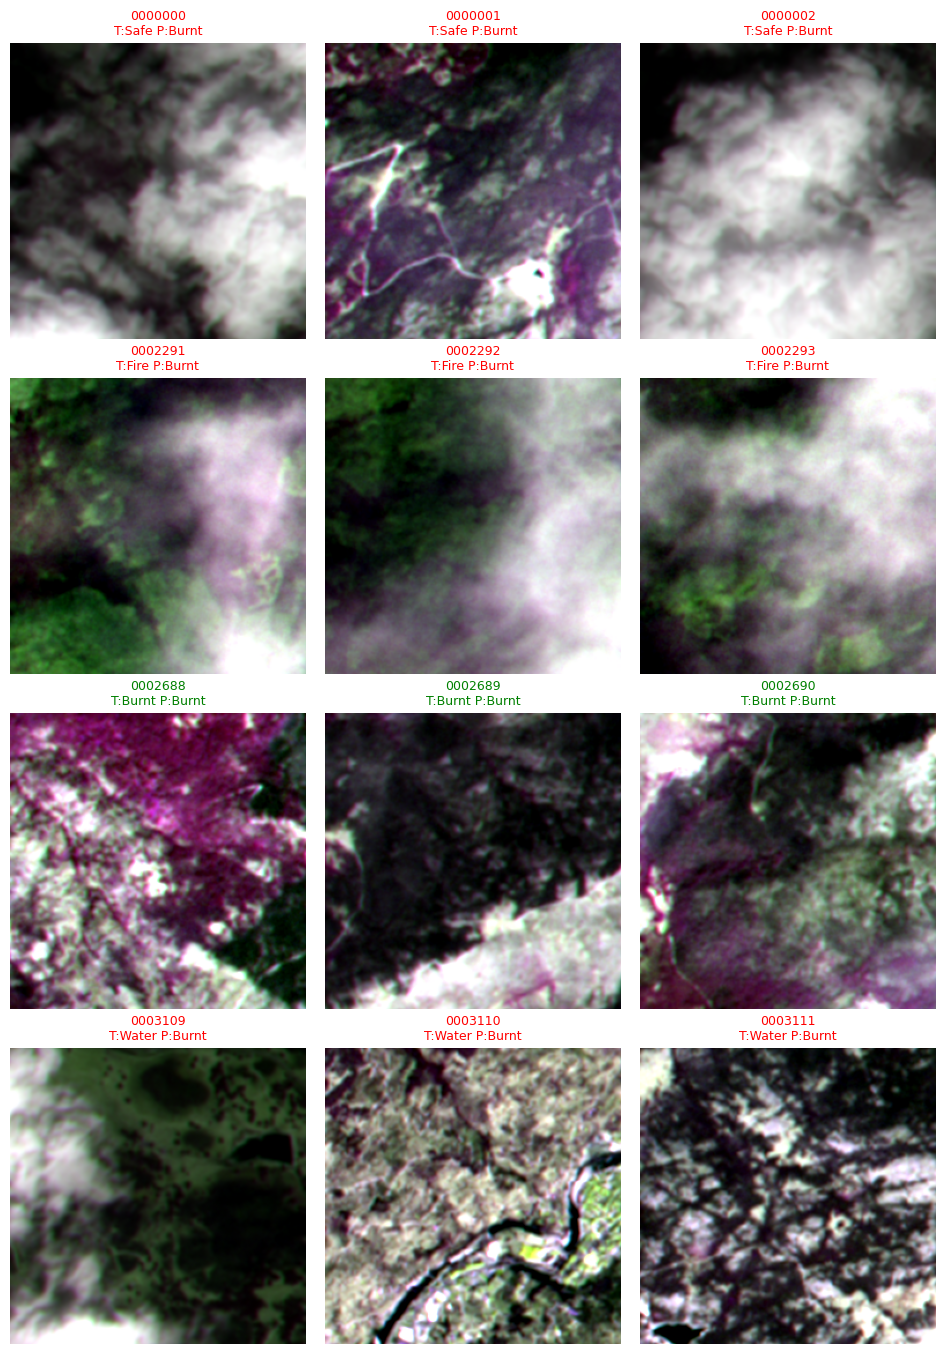

In [8]:
import matplotlib.pyplot as plt


def render_rgb(image_chw: np.ndarray, bands: tuple[int, int, int] = RGB_BANDS) -> np.ndarray:
    available = image_chw.shape[0]
    if max(bands) >= available:
        bands = tuple(range(min(3, available)))
    rgb = np.stack([image_chw[idx] for idx in bands], axis=-1)
    lo = np.nanpercentile(rgb, 2, axis=(0, 1), keepdims=True)
    hi = np.nanpercentile(rgb, 98, axis=(0, 1), keepdims=True)
    return np.clip((rgb - lo) / (hi - lo + 1e-6), 0.0, 1.0)


records_by_class = {class_id: [] for class_id in range(len(CLASS_NAMES))}
for record_index, record in enumerate(records):
    records_by_class[record["label"]].append(record_index)

n_rows = len(CLASS_NAMES)
n_cols = max(len(indices) for indices in records_by_class.values())
fig, axes = plt.subplots(n_rows, n_cols, figsize=(3.2 * n_cols, 3.4 * n_rows), squeeze=False)

for row_class_id, class_name in enumerate(CLASS_NAMES):
    indices = records_by_class[row_class_id]
    for col_idx in range(n_cols):
        ax = axes[row_class_id, col_idx]
        ax.axis("off")
        if col_idx >= len(indices):
            continue
        record_index = indices[col_idx]
        record = records[record_index]
        predicted_name = CLASS_NAMES[pred_class[record_index]]
        correct = pred_class[record_index] == target[record_index]
        ax.imshow(render_rgb(record["image"]))
        ax.set_title(
            f"{record['sample_id']}\nT:{class_name} P:{predicted_name}",
            color="green" if correct else "red",
            fontsize=9,
        )

fig.tight_layout()
output_path = OUTPUT_DIR / "fire_tile_validation_montage.png"
fig.savefig(output_path, dpi=160, bbox_inches="tight")
print(f"saved: {output_path}")
plt.show()


## Prediction Probability Heatmap

This compact view makes class confusion easier to inspect than reading raw probabilities tile by tile.


saved: /Users/roberto.delprete/.cache/hydranet/fire/outputs/fire_tile_probability_heatmap.png


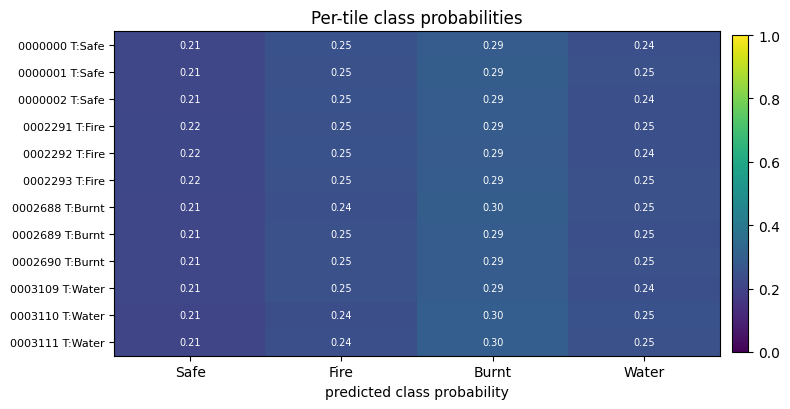

In [9]:
fig, ax = plt.subplots(figsize=(8, max(4, 0.35 * len(records))))
heatmap = ax.imshow(probabilities_np, aspect="auto", vmin=0, vmax=1, cmap="viridis")
ax.set_xticks(np.arange(len(CLASS_NAMES)))
ax.set_xticklabels(CLASS_NAMES)
ax.set_yticks(np.arange(len(records)))
ax.set_yticklabels([f"{record['sample_id']} T:{record['label_name']}" for record in records], fontsize=8)
ax.set_xlabel("predicted class probability")
ax.set_title("Per-tile class probabilities")
for row in range(len(records)):
    for col in range(len(CLASS_NAMES)):
        ax.text(col, row, f"{probabilities_np[row, col]:.2f}", ha="center", va="center", color="white", fontsize=7)
fig.colorbar(heatmap, ax=ax, fraction=0.025, pad=0.02)
fig.tight_layout()
output_path = OUTPUT_DIR / "fire_tile_probability_heatmap.png"
fig.savefig(output_path, dpi=160, bbox_inches="tight")
print(f"saved: {output_path}")
plt.show()


## Quick Failure Checks

If the predictions are clearly wrong, check these first:

- The task is 4-class tile classification: `Safe`, `Fire`, `Burnt`, `Water`.
- Do not convert labels to binary and do not center-crop to 224.
- Keep the input as `256 x 256` tiles, or tile larger acquisitions with `tile_chw_image`.
- `test` contains all four classes; the compact `trainval` subset in the public Zarr tree only exposes `Safe` and `Fire` labels.
- RGB rendering is only for display. The model receives all eight stored bands in B1-B8 order.
